In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import tifffile as tf
from glob import glob
import os
import tifffile as tf

from scipy import ndimage, stats, optimize, interpolate

#from fastkde import fastKDE
from KDEpy import FFTKDE
from KDEpy.bw_selection import improved_sheather_jones as ISJ

In [2]:
struc1 = ndimage.generate_binary_structure(2,1)
struc2 = ndimage.generate_binary_structure(2,2)

wsrc = '../cell_dams/'
nsrc = '../nuclear_mask/'
csrc = '../data/'
dst = '../results/'

sample = 'B1'
pows2 = 2**np.arange(20) + 1

In [3]:
wall = tf.imread(wsrc + sample + '_dams.tif').astype(bool)
edt = tf.imread(nsrc + sample + '_EDT.tif')
nuclei = edt < 2
ncoords = np.array(np.nonzero(nuclei))
wcoords = np.array(np.nonzero(~wall))
#imgcenter = np.array(wall.shape)//2

In [4]:
pad = 5
cy,cx = wall.shape
cx += int(np.where( cx % pad, cx%pad, pad))
cy += int(np.where( cy % pad, cy%pad, pad))

xaxis = np.arange(0, cx, pad)
yaxis = np.arange(0, cy, pad)
print(len(xaxis), len(yaxis), sep='\t')

mx = np.nonzero(pows2 > 1.5*len(xaxis))[0][0]
my = np.nonzero(pows2 > 1.5*len(yaxis))[0][0]

print(mx,my, sep='\t')

foo = pows2[mx] - len(xaxis)
xneg = foo//2
if foo % 2 == 0:
    xpos = foo//2
else:
    xpos = foo//2 + 1
print(pows2[mx], foo, xneg, xpos, xneg + len(xaxis) + xpos, sep='\t')

foo = pows2[my] - len(yaxis)
yneg = foo//2
if foo % 2 == 0:
    ypos = foo//2
else:
    ypos = foo//2 + 1
    
print(pows2[my], foo, yneg, ypos, yneg + len(yaxis) + ypos, sep='\t')

xaxes = np.hstack((np.arange(-xneg, 0, 1)*pad, xaxis, np.arange(len(xaxis), len(xaxis)+xpos, 1)*pad))
yaxes = np.hstack((np.arange(-yneg, 0, 1)*pad, yaxis, np.arange(len(yaxis), len(yaxis)+ypos, 1)*pad))
X,Y = np.meshgrid(xaxis, yaxis)
XX, YY = np.meshgrid(xaxes, yaxes)

grid = np.column_stack((np.ravel(XX, 'F'), np.ravel(YY, 'F')))
mask = (grid[:,0] > -1) & (grid[:,0] < cx) & (grid[:,1] > -1) & (grid[:,1] < cy)

print(XX.shape, len(xaxes) , len(yaxes), np.sum(mask), sep='\t')

2145	3003
12	13
4097	1952	976	976	4097
8193	5190	2595	2595	8193
(8193, 4097)	4097	8193	6441435


In [5]:
transcriptomes = sorted([foo.split('/')[-2] for foo in glob(csrc + sample + '_data/*/')])
print(len(transcriptomes), 'transcriptomes')

filename = csrc + sample + '_data/32771-slide1_' + sample + '_results.txt'
data = pd.read_csv(filename, header=None, sep='\t').drop(columns=[4])
data.columns = ['X', 'Y', 'Z', 'T']

tsize = np.arange(len(transcriptomes))
for tidx in range(len(tsize)):
    tcoords = data.loc[ data['T'] == transcriptomes[tidx] , ['X', 'Y', 'Z'] ].values.T
    tsize[tidx] = tcoords.shape[1]

targsort = np.argsort(tsize)[::-1]
for tidx in range(20):
    print(tidx+1, targsort[tidx], transcriptomes[targsort[tidx]], tsize[targsort[tidx]] , sep='\t')
    
print(data.shape)
data.iloc[:,:3].describe().drop(index='count').T.astype(dict(zip(['min','25%','50%','75%','max'], [int for i in range(5)])))

97 transcriptomes
1	26	GLYMA_05G092200	50577
2	57	GLYMA_11G008000	42563
3	28	GLYMA_05G216000	34377
4	32	GLYMA_06G168300	18417
5	72	GLYMA_15G169100	16513
6	43	GLYMA_08G125800	4259
7	10	CYP93A1	3023
8	62	GLYMA_12G027400	2463
9	12	GLYMA_01G019200	2317
10	19	GLYMA_03G029900	2261
11	90	GLYMA_18G197400	1843
12	53	GLYMA_10G070200	1815
13	50	GLYMA_09G216800	1726
14	84	GLYMA_17G185800	1607
15	25	GLYMA_05G023700	1537
16	70	GLYMA_15G008500	1105
17	79	GLYMA_16G165900	942
18	16	GLYMA_02G003700	914
19	41	GLYMA_08G011100	883
20	30	GLYMA_06G065000	825
(200807, 4)


,mean,std,min,25%,50%,75%,max
X,3996.593530,2315.313975,2,2071,3707,5417,10700
Y,7501.272142,2985.364623,19,5425,7353,9564,14983
Z,42.640625,10.645688,10,35,42,50,78


In [6]:
tidx = 10

tcoords = data.loc[ data['T'] == transcriptomes[tidx] , ['X', 'Y', 'Z'] ].values.T
nmask = ~nuclei[ tcoords[1], tcoords[0] ]

coords = tcoords[:2, nmask]
#np.savetxt('foo.csv', coords, delimiter=',', fmt='%d')
print(np.sum(nmask), len(nmask) - np.sum(nmask), np.round(100*np.sum(nmask)/len(nmask),1), '%\n---', sep='\t')

2244	779	74.2	%
---


# Do KDE

## fastKDE method

In [8]:
if False:
    
    ss = np.s_[yneg:-ypos, xneg:-xpos]
    fpdf0, vals0 = fastKDE.pdf(*coords, axes=[xaxes, yaxes], 
                               doApproximateECF=True, ecfPrecision=2, beVerbose = True, positiveShift = True)
    print(fpdf0.shape, fpdf0.min(), fpdf0.max())
    
    def normFunc(delta):
            """Calculate how far off from normal is the shifted PDF"""
            ipos = np.nonzero((fpdf0-delta) >= 0.0)
            return 1 - np.sum(fpdf0[ipos]-delta)*pad*pad
    
    if len(np.nonzero(fpdf0 < 0)[0]) != 0:
        delta, optilog = optimize.brentq(normFunc, 0,1e-4, maxiter=200, full_output=True)
        fpdf1 = fpdf0.copy() - delta
        fpdf1[fpdf1 < 0 ] = 0
        print(np.abs(1 - np.sum(fpdf1)*pad*pad), '\n', optilog, sep='')
        pdf = fpdf1[ss].copy()/(np.sum(fpdf1[ss])*pad*pad)    
    else:
        pdf = fpdf0[ss].copy()/(np.sum(fpdf0[ss])*pad*pad)

## KDEpy FFTKDE method

In [7]:
bw = np.zeros(len(coords))
for i in range(len(bw)):
    bw[i] = ISJ(coords[ i ].reshape(-1,1))
print(bw)

coords_scaled = coords/bw.reshape(-1,1)
kde_scaled = FFTKDE(kernel='gaussian', bw=1, norm=2).fit(coords_scaled.T).evaluate(grid/bw)
isj0 = kde_scaled / np.prod(bw)
print(np.sum(isj0)*pad**2)

[46.66248378 42.5203234 ]
0.9999140668226942


In [8]:
isj = isj0[mask]/(np.sum(isj0[mask])*pad**2)
isj = isj.reshape( ( len(yaxis), len(xaxis) ), order='F')

print(isj.shape, np.sum(isj)*pad**2)

(3003, 2145) 1.000000000000001


In [53]:
kdst = '../kde/'
kdst = kdst + sample + '/'
if not os.path.isdir(kdst):
    os.mkdir(kdst)
filename = kdst + 'meta_' + sample + '_' + transcriptomes[tidx] + '.csv'
meta = [np.sum(nmask), *bw, isj.min(), isj.max()]
pd.DataFrame(meta, columns=[transcriptomes[tidx]]).T.to_csv(filename, index=True, header=False)
filename = kdst + 'kde_' + sample + '_' + transcriptomes[tidx] + '.npy'
np.save(filename, isj)

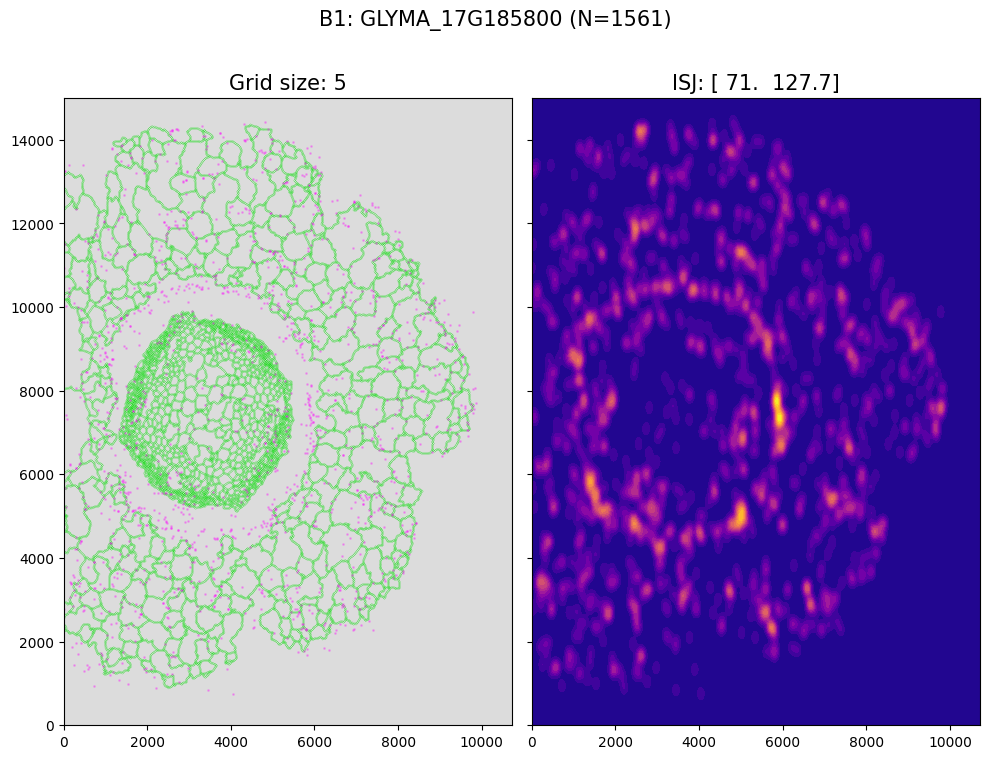

In [12]:
fs = 15
fig, ax = plt.subplots(1,2,figsize=(10,8), sharex=True, sharey=True)
ax = np.atleast_1d(ax).ravel()

ax[0].set_facecolor('gainsboro')
ax[0].scatter(wcoords[1], wcoords[0], c='lime', s=.01, marker='.', alpha=0.1, zorder=1);
ax[0].scatter(*coords, c='magenta', marker='o', s=1, zorder=2, alpha=0.25)

ax[1].contourf(xaxis, yaxis, isj, 16, cmap='plasma', vmin=0, zorder=1)
#ax[2].contourf(xaxis, yaxis, pdf, 16, cmap='plasma', vmin=0, zorder=1)

for i in range(len(ax)):
    ax[i].set_aspect('equal')
    ax[i].margins(0)
    ax[i].tick_params(labelsize=fs-5)

ax[0].set_title('Grid size: {}'.format(pad), fontsize=fs)
ax[1].set_title('ISJ: {}'.format(np.round(bw,1)), fontsize=fs)

fig.suptitle('{}: {} (N={})'.format(sample, transcriptomes[tidx], np.sum(nmask)), fontsize=fs);
fig.tight_layout();

#filename = kdst + '{}_-_{}_kde'.format(sample, transcriptomes[tidx])
#print(filename)
#plt.savefig(filename + '.jpg', format='jpg', dpi=150, bbox_inches='tight', pil_kwargs={'optimize':True})

# Individual cells

In [15]:
interp = interpolate.RegularGridInterpolator((yaxis, xaxis), isj, method='linear', bounds_error=True, fill_value=None)
bins = np.linspace(0, isj.max(), 256)

In [16]:
label, cellnum = ndimage.label(wall, struc1)
objss = ndimage.find_objects(label)
#hist, bins = np.histogram(label, bins=range(1,cellnum+2))
#cnuclei = np.asarray(ndimage.center_of_mass(wall, label, range(1,cellnum+1)))
print('Detected',cellnum,'cells')

Detected 1662 cells


In [34]:
csizes = np.zeros((len(objss), 4))
for i in range(len(csizes)):
    csizes[i,0] = objss[i][0].stop - objss[i][0].start
    csizes[i,1] = objss[i][1].stop - objss[i][1].start
    csizes[i,2] = csizes[i,0]/csizes[i,1]
    csizes[i,3] = csizes[i,1]/csizes[i,0]

pd.DataFrame(csizes, columns=['X', 'Y', 'X/Y', 'Y/X']).describe()

,X,Y,X/Y,Y/X
count,1662.000000,1662.000000,1662.000000,1662.000000
mean,231.392298,203.286402,1.140593,0.957939
std,469.976162,355.388183,0.364748,0.294042
min,16.000000,21.000000,0.355556,0.183133
25%,71.000000,68.000000,0.905231,0.766141
50%,119.000000,109.000000,1.092611,0.915239
75%,252.750000,229.750000,1.305243,1.104691
max,15008.000000,10720.000000,5.460526,2.812500


In [35]:
tpercell = np.zeros((cellnum), dtype=int)
for i in range(cellnum):
    lmask = label[ coords[1], coords[0] ] == i + 1
    tpercell[i] = np.sum(lmask)

tpcargsort = np.argsort( tpercell )[::-1]
for i in range(15):
    print(i, tpcargsort[i], csizes[tpcargsort[i]][:2].astype(int), tpercell[tpcargsort[i]], sep='\t')

0	113	[7144 5872]	334
1	0	[15008 10720]	147
2	1602	[1366 1323]	21
3	146	[1034 1010]	19
4	122	[1647 1253]	16
5	1271	[1403  968]	14
6	440	[2068  658]	13
7	1621	[2020  692]	13
8	47	[960 672]	12
9	69	[1358  519]	11
10	1562	[540 523]	11
11	1260	[937 775]	11
12	1567	[1563 1370]	10
13	1511	[760 781]	10
14	603	[905 789]	9


In [17]:
cidx = 0
ss = objss[cidx]
css = (np.s_[ss[0].start // pad : ss[0].stop // pad + 2], np.s_[ss[1].start // pad : ss[1].stop // pad + 2 ])
cxs = xaxis[css[1]]
cys = yaxis[css[0]]
cisj = isj[css]

ss = (np.s_[ cys[0]:cys[-1] ], np.s_[ cxs[0]:cxs[-1] ])
extent = (ss[1].start, ss[1].stop, ss[0].start, ss[0].stop)

cell = wall[ss].copy().astype(np.uint8)
cell[ label[ss] == cidx+1 ] += 1

ccoords = coords[:2, label[ coords[1], coords[0] ] == cidx + 1 ].copy()

wcellcoords = np.asarray(np.nonzero(~wall[ss]))
wcellcoords[0] += ss[0].start
wcellcoords[1] += ss[1].start
print(cell.shape, ccoords.shape, ss, sep='\t')

cellcoords = np.asarray(np.nonzero(label == cidx + 1))
cvals = interp(cellcoords.T)

cpdf = np.zeros(cell.shape)
cpdf[cellcoords[0]-ss[0].start, cellcoords[1] - ss[1].start] = cvals
dig = np.digitize(cpdf, bins, right=True).astype(np.uint8)

(15008, 10720)	(2, 147)	(slice(0, 15010, None), slice(0, 10720, None))


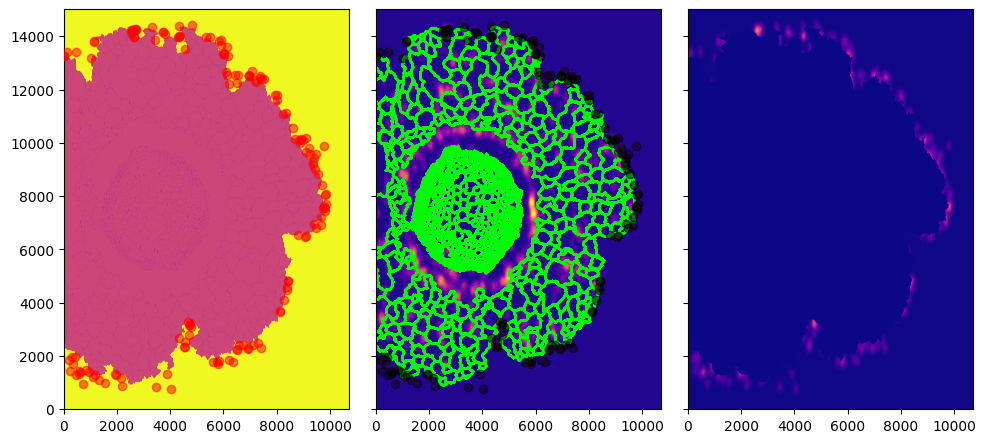

In [18]:
fig, ax = plt.subplots(1,3,figsize=(10,5), sharex=True, sharey=True)
ax = np.atleast_1d(ax).ravel()

ax[0].imshow(cell, cmap='plasma', origin='lower', extent=extent)
ax[0].scatter(ccoords[0], ccoords[1], c='red', marker='o', zorder=3, alpha=0.5);

ax[1].contourf(cxs, cys, cisj, 16, cmap='plasma', vmin=0, zorder=1)
ax[1].scatter(wcellcoords[1], wcellcoords[0], c='lime', marker='.', s=0.1)
ax[1].scatter(ccoords[0], ccoords[1], c='cyan', marker='o', zorder=3, alpha=0.5);

ax[2].imshow(dig, origin='lower', cmap='plasma', extent=extent, vmax=255)
#ax[2].scatter(wcellcoords[1], wcellcoords[0], c='lime', marker='.', s=0.001)

step = int(np.ediff1d(ax[0].get_xticks())[0])
for i in range(len(ax)):
    #ax[i].set_xticks(np.arange(0, cell.shape[1], step), np.arange(ss[1].start, ss[1].stop, step))
    #ax[i].set_yticks(np.arange(0, cell.shape[0], step), np.arange(ss[0].start, ss[0].stop, step))
    ax[i].set_aspect('equal')
    ax[i].margins(0)

fig.tight_layout();

In [19]:
dst = '../proc/'

sdst = dst + sample + '/'
if not os.path.isdir(sdst):
    os.mkdir(sdst)

tdst = sdst + transcriptomes[tidx] + '/'
if not os.path.isdir(tdst):
    os.mkdir(tdst)

filename = tdst + transcriptomes[tidx] + '_-_{:05d}.tif'.format(cidx)
print(filename)
tf.imwrite(filename, dig, photometric='minisblack')

../proc/B1/GLYMA_17G185800/GLYMA_17G185800_-_00000.tif
